# Práctica EDA 2: Auto MPG

#### 1. Carga del dataset y primer contacto

Carga `auto_mpg.csv` y realiza el primer contacto con el dataset. Reporta dimensiones, primeras filas, tipos de datos y define qué representa una fila.

Pista de trabajo: `shape`, `head()`, `info()` y `dtypes`.

In [1]:
# Ejercicio 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datos_autos = pd.read_csv("../data/auto_mpg.csv")

print("Dimensiones del dataset:", datos_autos.shape)
print("\nTipos de datos:")
print(datos_autos.dtypes)
print("\nInformación general:")
datos_autos.info()

datos_autos.head()

Dimensiones del dataset: (398, 9)

Tipos de datos:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


Una fila representa un automóvil registrado en el dataset, con sus características de consumo, motor, peso, aceleración, año, origen y nombre del modelo.

#### 2. Clasificación de variables

Clasifica `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`, `origin` y `name`. Identifica qué variables conviene tratar como categorías o temporales.

In [2]:
# Ejercicio 2
clasificacion_variables = pd.DataFrame({
    "variable": [
        "mpg", "cylinders", "displacement", "horsepower", "weight",
        "acceleration", "model_year", "origin", "name"
    ],
    "tipo_analitico": [
        "numérica continua",
        "categórica ordinal/discreta",
        "numérica continua",
        "numérica continua",
        "numérica continua",
        "numérica continua",
        "temporal discreta",
        "categórica nominal",
        "categórica nominal"
    ],
    "comentario": [
        "Variable objetivo: millas por galón.",
        "Aunque es numérica, representa grupos de cilindros.",
        "Cilindrada del motor.",
        "Potencia del motor; tiene algunos valores faltantes.",
        "Peso del vehículo.",
        "Tiempo de aceleración.",
        "Año del modelo; conviene analizarlo como tiempo.",
        "País o región de origen.",
        "Nombre del modelo; alta cardinalidad."
    ]
})

clasificacion_variables

,variable,tipo_analitico,comentario
0,mpg,numérica continua,Variable objetivo: millas por galón.
1,cylinders,categórica ordinal/discreta,"Aunque es numérica, representa grupos de cilin..."
2,displacement,numérica continua,Cilindrada del motor.
3,horsepower,numérica continua,Potencia del motor; tiene algunos valores falt...
4,weight,numérica continua,Peso del vehículo.
5,acceleration,numérica continua,Tiempo de aceleración.
6,model_year,temporal discreta,Año del modelo; conviene analizarlo como tiempo.
7,origin,categórica nominal,País o región de origen.
8,name,categórica nominal,Nombre del modelo; alta cardinalidad.


#### 3. Valores faltantes y duplicados exactos

Analiza valores faltantes y duplicados exactos. ¿En qué variable faltan datos y qué proporción representan?

In [3]:
# Ejercicio 3
valores_faltantes = datos_autos.isna().sum()
porcentaje_faltantes = datos_autos.isna().mean() * 100

resumen_faltantes = pd.DataFrame({
    "faltantes": valores_faltantes,
    "porcentaje": porcentaje_faltantes.round(2)
})

duplicados_exactos = datos_autos.duplicated().sum()

print("Duplicados exactos:", duplicados_exactos)
resumen_faltantes

Duplicados exactos: 0


,faltantes,porcentaje
mpg,0,0.00
cylinders,0,0.00
displacement,0,0.00
horsepower,6,1.51
weight,0,0.00
acceleration,0,0.00
model_year,0,0.00
origin,0,0.00
name,0,0.00


La variable con valores faltantes es `horsepower`. Son pocos casos respecto del total, por lo que para algunas correlaciones se pueden usar solo filas completas en esa variable.

#### 4. Cardinalidad de `name`

Estudia la cardinalidad de `name`. ¿Cuántos nombres distintos hay? ¿Que un nombre aparezca varias veces significa que las filas son duplicadas? Compruébalo con ejemplos.

In [4]:
# Ejercicio 4
nombres_distintos = datos_autos["name"].nunique()
nombres_repetidos = datos_autos["name"].value_counts()

print("Nombres distintos:", nombres_distintos)
print("\nNombres que más se repiten:")
print(nombres_repetidos.head(10))

nombre_ejemplo = nombres_repetidos[nombres_repetidos > 1].index[0]
print("\nEjemplo de un nombre repetido:", nombre_ejemplo)

datos_autos[datos_autos["name"] == nombre_ejemplo]

Nombres distintos: 305

Nombres que más se repiten:
name
ford pinto            6
toyota corolla        5
amc matador           5
ford maverick         5
chevrolet chevette    4
amc gremlin           4
chevrolet impala      4
peugeot 504           4
amc hornet            4
toyota corona         4
Name: count, dtype: int64

Ejemplo de un nombre repetido: ford pinto


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
32,25.0,4,98.0,NaN,2046,19.0,71,usa,ford pinto
112,19.0,4,122.0,85.0,2310,18.5,73,usa,ford pinto
130,26.0,4,122.0,80.0,2451,16.5,74,usa,ford pinto
168,23.0,4,140.0,83.0,2639,17.0,75,usa,ford pinto
174,18.0,6,171.0,97.0,2984,14.5,75,usa,ford pinto
206,26.5,4,140.0,72.0,2565,13.6,76,usa,ford pinto


Un nombre repetido no implica un duplicado exacto. Puede tratarse del mismo modelo en distintos años o con características diferentes.

#### 5. Estadísticos descriptivos de `mpg`, `weight` y `horsepower`

Calcula media, mediana, desviación estándar, cuartiles e IQR. Interpreta qué dicen sobre un automóvil típico y sobre la dispersión.

In [5]:
# Ejercicio 5
variables_interes = ["mpg", "weight", "horsepower"]

estadisticos = datos_autos[variables_interes].describe().T
estadisticos["mediana"] = datos_autos[variables_interes].median()
estadisticos["IQR"] = estadisticos["75%"] - estadisticos["25%"]

estadisticos[["mean", "mediana", "std", "25%", "50%", "75%", "IQR"]]

,mean,mediana,std,25%,50%,75%,IQR
mpg,23.514573,23.0,7.815984,17.50,23.0,29.0,11.50
weight,2970.424623,2803.5,846.841774,2223.75,2803.5,3608.0,1384.25
horsepower,104.469388,93.5,38.491160,75.00,93.5,126.0,51.00


La mediana describe mejor al automóvil típico cuando hay valores extremos. El IQR ayuda a ver la dispersión central sin depender tanto de los outliers.

#### 6. Distribución de `mpg`

Analiza la distribución de `mpg` con histograma y KDE.

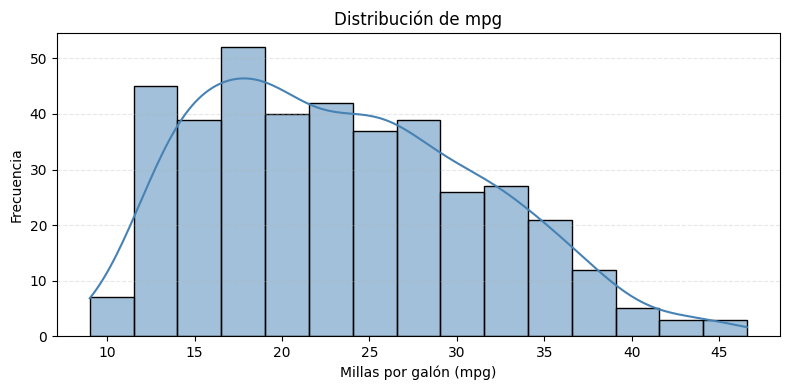

In [6]:
# Ejercicio 6
plt.figure(figsize=(8, 4))
sns.histplot(datos_autos["mpg"], bins=15, kde=True, color="steelblue")
plt.title("Distribución de mpg")
plt.xlabel("Millas por galón (mpg)")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

#### 7. Distribución de `weight` y outliers por IQR

Analiza `weight` con histograma y boxplot. ¿La distribución es simétrica? ¿Hay valores extremos según la regla del IQR? Documenta el cálculo.

Q1: 2223.75
Q3: 3608.0
IQR: 1384.25
Límite inferior: 147.375
Límite superior: 5684.375
Cantidad de outliers: 0


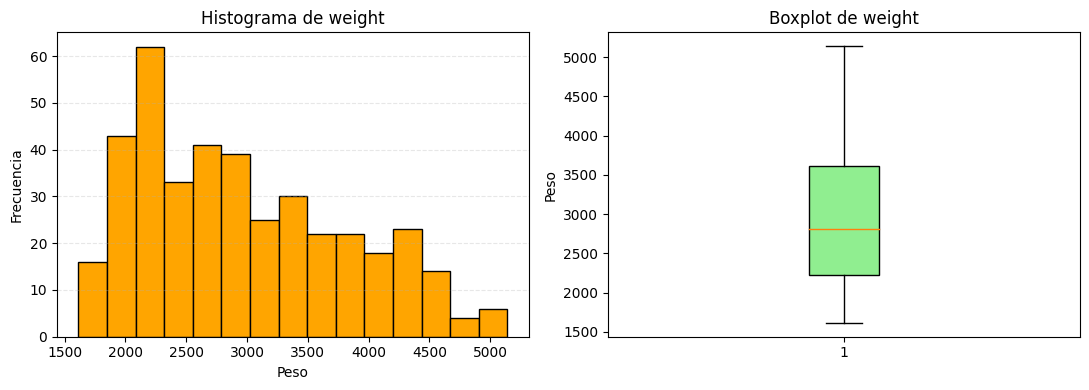

,name,weight,mpg,cylinders,origin


In [7]:
# Ejercicio 7
q1_weight = datos_autos["weight"].quantile(0.25)
q3_weight = datos_autos["weight"].quantile(0.75)
iqr_weight = q3_weight - q1_weight
limite_inferior_weight = q1_weight - 1.5 * iqr_weight
limite_superior_weight = q3_weight + 1.5 * iqr_weight

outliers_weight = datos_autos[
    (datos_autos["weight"] < limite_inferior_weight) |
    (datos_autos["weight"] > limite_superior_weight)
]

print("Q1:", q1_weight)
print("Q3:", q3_weight)
print("IQR:", iqr_weight)
print("Límite inferior:", limite_inferior_weight)
print("Límite superior:", limite_superior_weight)
print("Cantidad de outliers:", len(outliers_weight))

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.hist(datos_autos["weight"], bins=15, color="orange", edgecolor="black")
plt.title("Histograma de weight")
plt.xlabel("Peso")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(datos_autos["weight"], patch_artist=True, boxprops={"facecolor": "lightgreen"})
plt.title("Boxplot de weight")
plt.ylabel("Peso")

plt.tight_layout()
plt.show()

outliers_weight[["name", "weight", "mpg", "cylinders", "origin"]]

La distribución de `weight` no es perfectamente simétrica. Si aparecen outliers por IQR, deben revisarse en contexto porque pueden ser autos grandes y plausibles.

#### 8. Outliers en `horsepower`

Detecta outliers en `horsepower` usando 1.5·IQR. Lista los vehículos identificados y comenta si parecen errores evidentes o autos de alta potencia plausibles.

In [8]:
# Ejercicio 8
horsepower_sin_nulos = datos_autos["horsepower"].dropna()

q1_hp = horsepower_sin_nulos.quantile(0.25)
q3_hp = horsepower_sin_nulos.quantile(0.75)
iqr_hp = q3_hp - q1_hp
limite_inferior_hp = q1_hp - 1.5 * iqr_hp
limite_superior_hp = q3_hp + 1.5 * iqr_hp

outliers_hp_iqr = datos_autos[
    (datos_autos["horsepower"] < limite_inferior_hp) |
    (datos_autos["horsepower"] > limite_superior_hp)
].sort_values("horsepower", ascending=False)

print("Límite inferior:", limite_inferior_hp)
print("Límite superior:", limite_superior_hp)
print("Cantidad de outliers:", len(outliers_hp_iqr))

outliers_hp_iqr[["name", "horsepower", "mpg", "cylinders", "displacement", "weight", "origin"]]

Límite inferior: -1.5
Límite superior: 202.5
Cantidad de outliers: 10


,name,horsepower,mpg,cylinders,displacement,weight,origin
116,pontiac grand prix,230.0,16.0,8,400.0,4278,usa
8,pontiac catalina,225.0,14.0,8,455.0,4425,usa
13,buick estate wagon (sw),225.0,14.0,8,455.0,3086,usa
95,buick electra 225 custom,225.0,12.0,8,455.0,4951,usa
6,chevrolet impala,220.0,14.0,8,454.0,4354,usa
7,plymouth fury iii,215.0,14.0,8,440.0,4312,usa
25,ford f250,215.0,10.0,8,360.0,4615,usa
94,chrysler new yorker brougham,215.0,13.0,8,440.0,4735,usa
27,dodge d200,210.0,11.0,8,318.0,4382,usa
67,mercury marquis,208.0,11.0,8,429.0,4633,usa


Los outliers de `horsepower` suelen corresponder a autos de alta potencia. No parecen errores evidentes solo por ser altos; conviene revisar nombre, cilindros, desplazamiento y peso.

#### 9. Frecuencias de `cylinders` y `origin`

Explora `cylinders` y `origin` mediante frecuencias y gráficos de barras. ¿Qué categorías dominan el dataset? ¿Hay categorías con muy pocos casos?

Frecuencia por cilindros:
cylinders
3      4
4    204
5      3
6     84
8    103
Name: count, dtype: int64

Frecuencia por origen:
origin
usa       249
japan      79
europe     70
Name: count, dtype: int64


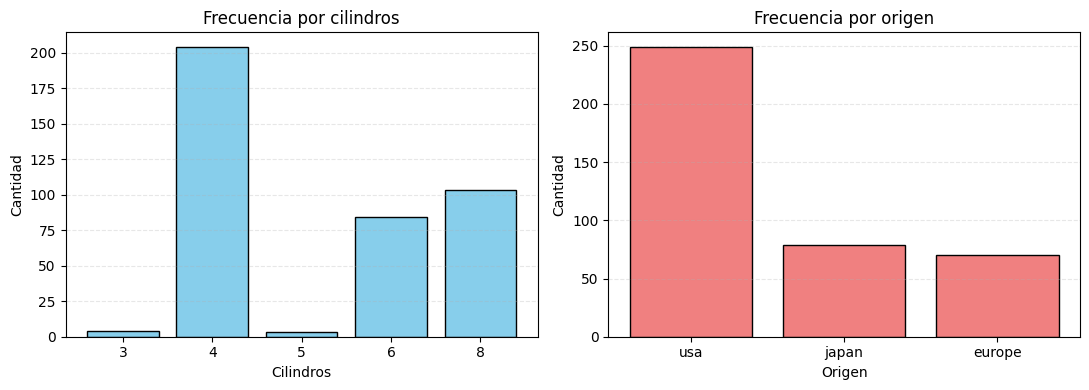

In [9]:
# Ejercicio 9
frecuencia_cilindros = datos_autos["cylinders"].value_counts().sort_index()
frecuencia_origen = datos_autos["origin"].value_counts()

print("Frecuencia por cilindros:")
print(frecuencia_cilindros)
print("\nFrecuencia por origen:")
print(frecuencia_origen)

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.bar(frecuencia_cilindros.index.astype(str), frecuencia_cilindros.values, color="skyblue", edgecolor="black")
plt.title("Frecuencia por cilindros")
plt.xlabel("Cilindros")
plt.ylabel("Cantidad")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(frecuencia_origen.index, frecuencia_origen.values, color="lightcoral", edgecolor="black")
plt.title("Frecuencia por origen")
plt.xlabel("Origen")
plt.ylabel("Cantidad")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Suelen dominar los autos de 4 cilindros y de origen `usa`. Las categorías de 3 y 5 cilindros tienen muy pocos casos, por lo que sus comparaciones son menos estables.

#### 10. `mpg` por número de cilindros

Compara `mpg` entre vehículos con distinto número de cilindros mediante boxplot y medias/medianas por grupo.

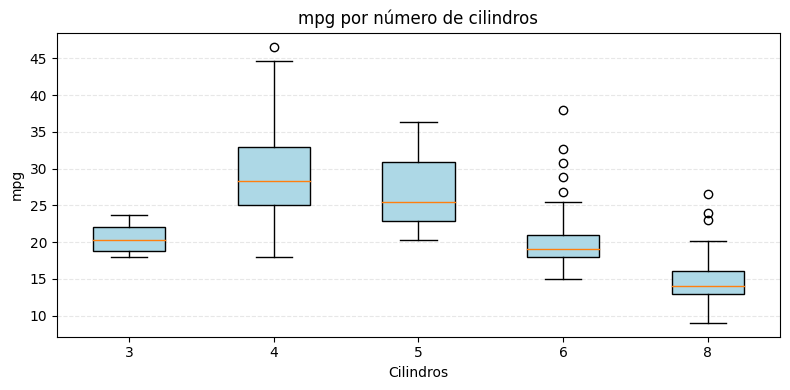

,count,mean,median
cylinders,,,
3,4,20.55,20.25
4,204,29.29,28.25
5,3,27.37,25.40
6,84,19.99,19.00
8,103,14.96,14.00


In [10]:
# Ejercicio 10
resumen_mpg_cilindros = datos_autos.groupby("cylinders")["mpg"].agg(["count", "mean", "median"]).round(2)

datos_boxplot = [
    datos_autos[datos_autos["cylinders"] == cilindro]["mpg"]
    for cilindro in sorted(datos_autos["cylinders"].unique())
]
etiquetas_cilindros = sorted(datos_autos["cylinders"].unique())

plt.figure(figsize=(8, 4))
plt.boxplot(datos_boxplot, patch_artist=True, boxprops={"facecolor": "lightblue"})
plt.xticks(range(1, len(etiquetas_cilindros) + 1), etiquetas_cilindros)
plt.title("mpg por número de cilindros")
plt.xlabel("Cilindros")
plt.ylabel("mpg")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

resumen_mpg_cilindros

El patrón general es que los autos con menos cilindros tienden a tener mayor `mpg`, mientras que los de 8 cilindros suelen consumir más combustible.

#### 11. `mpg` por origen

Compara `mpg` entre los tres orígenes del dataset. Usa boxplot y estadísticas por grupo.

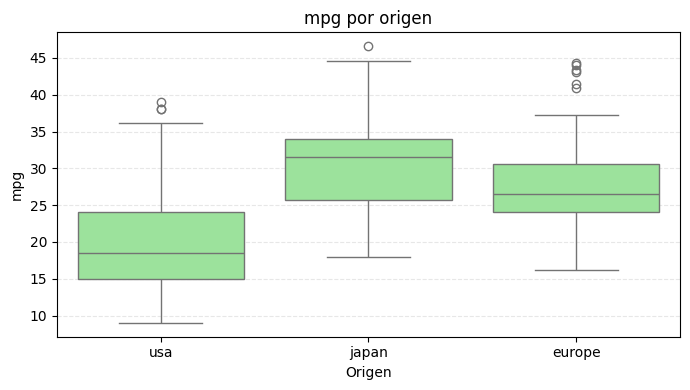

,count,mean,median,std
origin,,,,
europe,70,27.89,26.5,6.72
japan,79,30.45,31.6,6.09
usa,249,20.08,18.5,6.40


In [11]:
# Ejercicio 11
resumen_mpg_origen = datos_autos.groupby("origin")["mpg"].agg(["count", "mean", "median", "std"]).round(2)

plt.figure(figsize=(7, 4))
sns.boxplot(data=datos_autos, x="origin", y="mpg", color="lightgreen")
plt.title("mpg por origen")
plt.xlabel("Origen")
plt.ylabel("mpg")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

resumen_mpg_origen

Las diferencias por origen pueden estar mezcladas con peso, cilindrada, año y otras variables. Por eso no conviene interpretarlas como una causa directa.

#### 12. Relación entre `weight` y `mpg`

Estudia la relación entre `weight` y `mpg` con un scatterplot y la correlación.

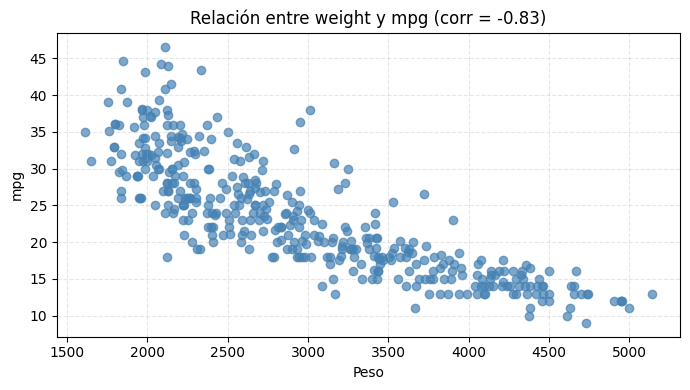

Correlación weight-mpg: -0.832


In [12]:
# Ejercicio 12
correlacion_weight_mpg = datos_autos["weight"].corr(datos_autos["mpg"])

plt.figure(figsize=(7, 4))
plt.scatter(datos_autos["weight"], datos_autos["mpg"], color="steelblue", alpha=0.7)
plt.title(f"Relación entre weight y mpg (corr = {correlacion_weight_mpg:.2f})")
plt.xlabel("Peso")
plt.ylabel("mpg")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print("Correlación weight-mpg:", round(correlacion_weight_mpg, 3))

La relación suele ser negativa: a mayor peso, menor rendimiento en millas por galón.

#### 13. Relación entre `horsepower` y `mpg`

Estudia la relación entre `horsepower` y `mpg` con scatterplot y correlación. Compara su intensidad con la relación `weight`-`mpg`.

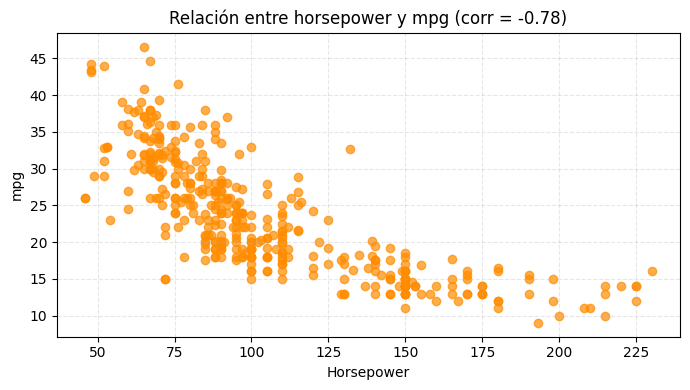

Correlación horsepower-mpg: -0.778
Correlación weight-mpg: -0.832


In [13]:
# Ejercicio 13
datos_hp_completos = datos_autos.dropna(subset=["horsepower"])

correlacion_hp_mpg = datos_hp_completos["horsepower"].corr(datos_hp_completos["mpg"])
correlacion_weight_mpg = datos_autos["weight"].corr(datos_autos["mpg"])

plt.figure(figsize=(7, 4))
plt.scatter(datos_hp_completos["horsepower"], datos_hp_completos["mpg"], color="darkorange", alpha=0.7)
plt.title(f"Relación entre horsepower y mpg (corr = {correlacion_hp_mpg:.2f})")
plt.xlabel("Horsepower")
plt.ylabel("mpg")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print("Correlación horsepower-mpg:", round(correlacion_hp_mpg, 3))
print("Correlación weight-mpg:", round(correlacion_weight_mpg, 3))

`horsepower` también suele tener relación negativa con `mpg`. Se compara con `weight` revisando cuál correlación tiene mayor valor absoluto.

#### 14. Matriz de correlación y heatmap

Construye una matriz de correlación y heatmap de las variables numéricas. Identifica las tres variables con mayor asociación lineal absoluta con `mpg` y comenta posibles redundancias.

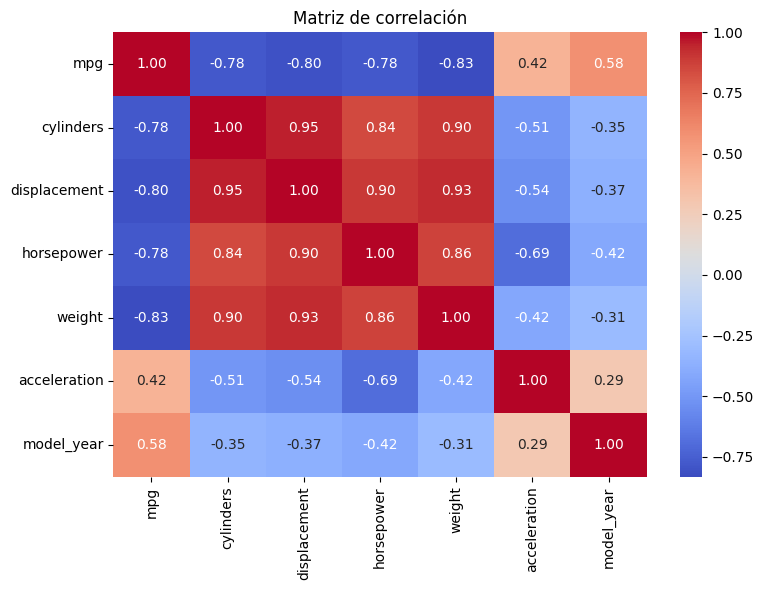

Tres variables más asociadas con mpg:
weight          0.831741
displacement    0.804203
horsepower      0.778427
Name: mpg, dtype: float64


In [14]:
# Ejercicio 14
variables_numericas = datos_autos.select_dtypes("number")
matriz_correlacion = variables_numericas.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

correlaciones_mpg = (
    matriz_correlacion["mpg"]
    .drop("mpg")
    .abs()
    .sort_values(ascending=False)
)

print("Tres variables más asociadas con mpg:")
print(correlaciones_mpg.head(3))

Variables como `weight`, `displacement`, `horsepower` y `cylinders` pueden ser redundantes entre sí porque describen tamaño o potencia del vehículo.

#### 15. Análisis multivariado con `weight`, `mpg`, `origin` y `cylinders`

Analiza `weight` frente a `mpg` incorporando `origin` y `cylinders`. Añade la evolución media de `mpg` por `model_year`.

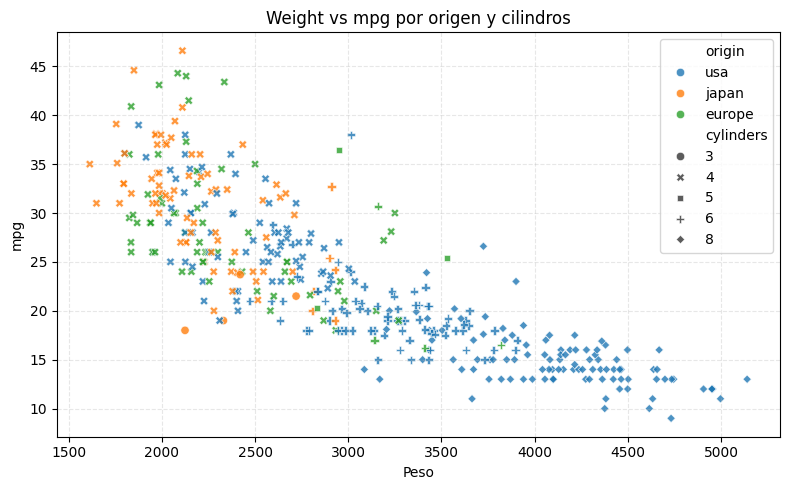

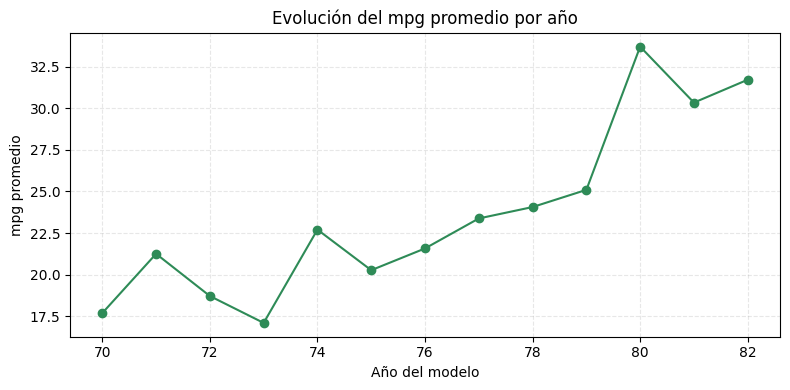

In [15]:
# Ejercicio 15
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=datos_autos,
    x="weight",
    y="mpg",
    hue="origin",
    style="cylinders",
    alpha=0.8
)
plt.title("Weight vs mpg por origen y cilindros")
plt.xlabel("Peso")
plt.ylabel("mpg")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

mpg_promedio_anual = datos_autos.groupby("model_year")["mpg"].mean()

plt.figure(figsize=(8, 4))
plt.plot(mpg_promedio_anual.index, mpg_promedio_anual.values, marker="o", color="seagreen")
plt.title("Evolución del mpg promedio por año")
plt.xlabel("Año del modelo")
plt.ylabel("mpg promedio")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

El patrón peso-`mpg` se mantiene de forma general: los autos más pesados tienden a tener menor rendimiento. El `mpg` promedio mejora con los años.

#### 16. Evolución de `mpg` por `model_year`

Calcula media y mediana por año y represéntalas en una gráfica de líneas.

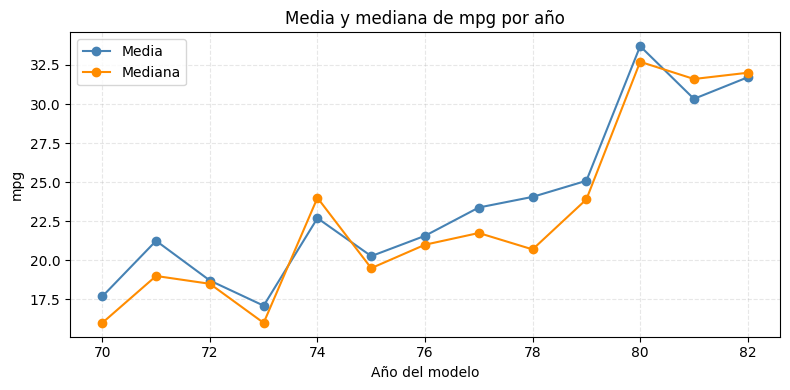

,mean,median
model_year,,
70,17.69,16.00
71,21.25,19.00
72,18.71,18.50
73,17.10,16.00
74,22.70,24.00
75,20.27,19.50
76,21.57,21.00
77,23.38,21.75
78,24.06,20.70


In [16]:
# Ejercicio 16
mpg_por_anio = datos_autos.groupby("model_year")["mpg"].agg(["mean", "median"]).round(2)

plt.figure(figsize=(8, 4))
plt.plot(mpg_por_anio.index, mpg_por_anio["mean"], marker="o", label="Media", color="steelblue")
plt.plot(mpg_por_anio.index, mpg_por_anio["median"], marker="o", label="Mediana", color="darkorange")
plt.title("Media y mediana de mpg por año")
plt.xlabel("Año del modelo")
plt.ylabel("mpg")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

mpg_por_anio

`model_year` funciona como una variable temporal discreta. La tendencia general muestra mejora del rendimiento con el tiempo.

#### 17. `weight` por `origin`

Compara el `weight` de los automóviles por `origin` mediante estadísticas y boxplots. ¿Puede la diferencia de peso ayudar a explicar parte de las diferencias de `mpg`?

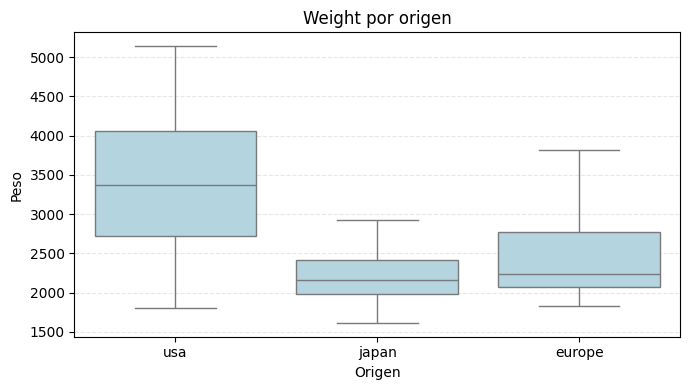

,count,mean,median,std
origin,,,,
europe,70,2423.30,2240.0,490.04
japan,79,2221.23,2155.0,320.50
usa,249,3361.93,3365.0,794.79


In [17]:
# Ejercicio 17
resumen_weight_origen = datos_autos.groupby("origin")["weight"].agg(["count", "mean", "median", "std"]).round(2)

plt.figure(figsize=(7, 4))
sns.boxplot(data=datos_autos, x="origin", y="weight", color="lightblue")
plt.title("Weight por origen")
plt.xlabel("Origen")
plt.ylabel("Peso")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

resumen_weight_origen

Si un origen concentra autos más livianos, eso puede explicar parte de su mayor `mpg`, porque `weight` está fuertemente asociado de forma negativa con el rendimiento.

#### 18. Patrón de nulos en `horsepower`

Compara la frecuencia de nulos de `horsepower` por `origin`, `cylinders` y `model_year`.

In [18]:
# Ejercicio 18
datos_autos["horsepower_faltante"] = datos_autos["horsepower"].isna()

nulos_por_origen = datos_autos.groupby("origin")["horsepower_faltante"].agg(["sum", "mean"])
nulos_por_cilindros = datos_autos.groupby("cylinders")["horsepower_faltante"].agg(["sum", "mean"])
nulos_por_anio = datos_autos.groupby("model_year")["horsepower_faltante"].agg(["sum", "mean"])

nulos_por_origen["mean"] = (nulos_por_origen["mean"] * 100).round(2)
nulos_por_cilindros["mean"] = (nulos_por_cilindros["mean"] * 100).round(2)
nulos_por_anio["mean"] = (nulos_por_anio["mean"] * 100).round(2)

print("Nulos por origen:")
print(nulos_por_origen)
print("\nNulos por cilindros:")
print(nulos_por_cilindros)
print("\nAños con nulos:")
print(nulos_por_anio[nulos_por_anio["sum"] > 0])

Nulos por origen:
        sum  mean
origin           
europe    2  2.86
japan     0  0.00
usa       4  1.61

Nulos por cilindros:
           sum  mean
cylinders           
3            0  0.00
4            5  2.45
5            0  0.00
6            1  1.19
8            0  0.00

Años con nulos:
            sum  mean
model_year           
71            1  3.57
74            1  3.70
80            2  6.90
81            1  3.45
82            1  3.23


Como son pocos valores faltantes, se puede describir el patrón, pero no conviene sacar conclusiones fuertes.

#### 19. Relación entre `acceleration` y `mpg`

Analiza la relación con scatterplot y correlación de Pearson. Compara su fuerza con las relaciones de `weight` y `horsepower` con `mpg`.

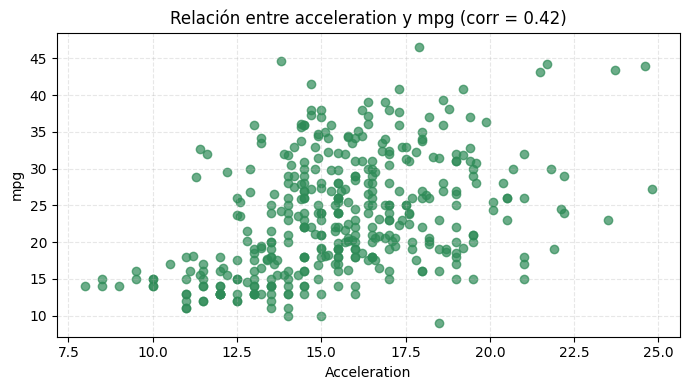

acceleration-mpg    0.420
weight-mpg         -0.832
horsepower-mpg     -0.778
dtype: float64

In [19]:
# Ejercicio 19
correlacion_acc_mpg = datos_autos["acceleration"].corr(datos_autos["mpg"])
correlacion_weight_mpg = datos_autos["weight"].corr(datos_autos["mpg"])
correlacion_hp_mpg = datos_autos.dropna(subset=["horsepower"])["horsepower"].corr(
    datos_autos.dropna(subset=["horsepower"])["mpg"]
)

plt.figure(figsize=(7, 4))
plt.scatter(datos_autos["acceleration"], datos_autos["mpg"], color="seagreen", alpha=0.7)
plt.title(f"Relación entre acceleration y mpg (corr = {correlacion_acc_mpg:.2f})")
plt.xlabel("Acceleration")
plt.ylabel("mpg")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

comparacion_correlaciones = pd.Series({
    "acceleration-mpg": correlacion_acc_mpg,
    "weight-mpg": correlacion_weight_mpg,
    "horsepower-mpg": correlacion_hp_mpg
}).round(3)

comparacion_correlaciones

`acceleration` puede aportar información, pero normalmente su relación con `mpg` es más débil que la de `weight` o `horsepower`.

#### 20. Relación entre `displacement`, `horsepower` y `weight`

Calcula sus correlaciones y crea gráficos de dispersión. ¿Qué problema podría aparecer si se usan simultáneamente como predictores sin revisar redundancias?

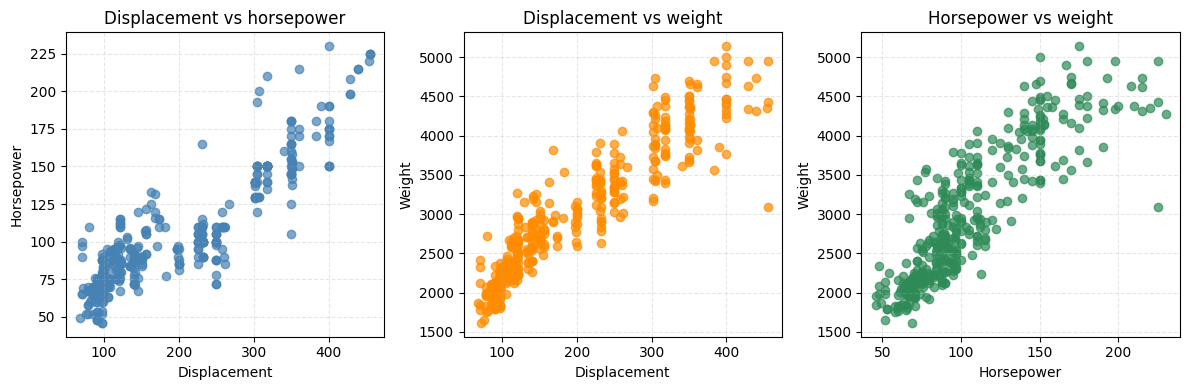

,displacement,horsepower,weight
displacement,1.000000,0.897257,0.932824
horsepower,0.897257,1.000000,0.864538
weight,0.932824,0.864538,1.000000


In [20]:
# Ejercicio 20
predictores_motor = ["displacement", "horsepower", "weight"]
correlaciones_predictores = datos_autos[predictores_motor].corr()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(datos_autos["displacement"], datos_autos["horsepower"], alpha=0.7, color="steelblue")
plt.xlabel("Displacement")
plt.ylabel("Horsepower")
plt.title("Displacement vs horsepower")
plt.grid(True, linestyle="--", alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(datos_autos["displacement"], datos_autos["weight"], alpha=0.7, color="darkorange")
plt.xlabel("Displacement")
plt.ylabel("Weight")
plt.title("Displacement vs weight")
plt.grid(True, linestyle="--", alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(datos_autos["horsepower"], datos_autos["weight"], alpha=0.7, color="seagreen")
plt.xlabel("Horsepower")
plt.ylabel("Weight")
plt.title("Horsepower vs weight")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

correlaciones_predictores

Si estos predictores están muy correlacionados, puede aparecer multicolinealidad o redundancia en modelos posteriores.

#### 21. Tabla pivote de `mpg` por `cylinders` y `origin`

Construye una tabla pivote con el `mpg` medio por `cylinders` y `origin`, incluyendo el número de automóviles por grupo. Señala grupos con muestras pequeñas.

In [21]:
# Ejercicio 21
tabla_pivote_media = pd.pivot_table(
    datos_autos,
    values="mpg",
    index="cylinders",
    columns="origin",
    aggfunc="mean"
).round(2)

tabla_pivote_conteo = pd.pivot_table(
    datos_autos,
    values="mpg",
    index="cylinders",
    columns="origin",
    aggfunc="count"
).fillna(0).astype(int)

grupos_pequenos = (
    datos_autos.groupby(["cylinders", "origin"])
    .size()
    .reset_index(name="cantidad")
    .query("cantidad < 5")
)

print("MPG medio:")
display(tabla_pivote_media)

print("Cantidad de autos:")
display(tabla_pivote_conteo)

print("Grupos con menos de 5 autos:")
grupos_pequenos

MPG medio:


origin,europe,japan,usa
cylinders,,,
3,NaN,20.55,NaN
4,28.41,31.60,27.84
5,27.37,NaN,NaN
6,20.10,23.88,19.66
8,NaN,NaN,14.96


Cantidad de autos:


origin,europe,japan,usa
cylinders,,,
3,0,4,0
4,63,69,72
5,3,0,0
6,4,6,74
8,0,0,103


Grupos con menos de 5 autos:


,cylinders,origin,cantidad
0,3,japan,4
4,5,europe,3
5,6,europe,4


El patrón por cilindros debe interpretarse con cuidado cuando algunos cruces de `cylinders` y `origin` tienen pocas observaciones.

#### 22. Evolución temporal de `mpg` por `origin`

Compara la evolución temporal de `mpg` entre `origin` usando líneas por grupo.

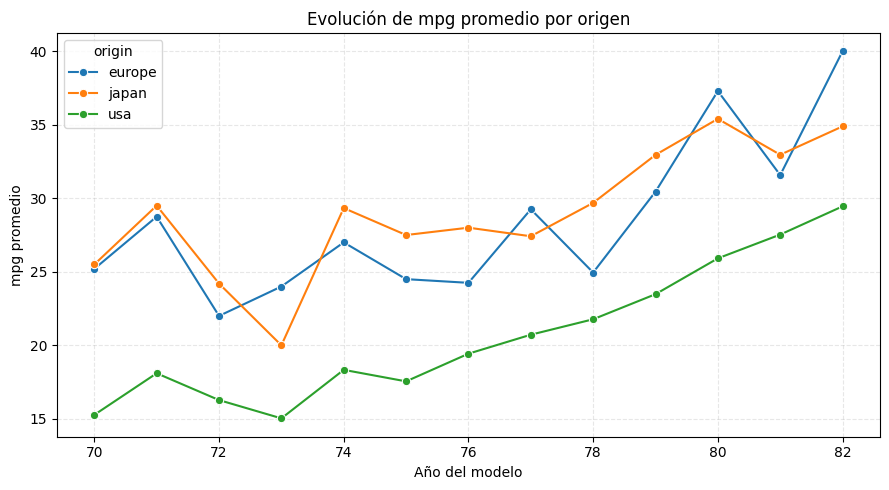

,model_year,origin,mpg
0,70,europe,25.200000
1,70,japan,25.500000
2,70,usa,15.272727
3,71,europe,28.750000
4,71,japan,29.500000


In [22]:
# Ejercicio 22
mpg_anual_origen = (
    datos_autos.groupby(["model_year", "origin"])["mpg"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))
sns.lineplot(data=mpg_anual_origen, x="model_year", y="mpg", hue="origin", marker="o")
plt.title("Evolución de mpg promedio por origen")
plt.xlabel("Año del modelo")
plt.ylabel("mpg promedio")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

mpg_anual_origen.head()

Los tres orígenes muestran mejora en varios años, pero la brecha no necesariamente se mantiene constante porque cambian los tipos de autos presentes en cada grupo.

#### 23. Outliers de `horsepower`: IQR vs z-score

Compara los outliers detectados mediante 1.5·IQR y mediante `|z| > 3`. Lista los vehículos más extremos y explica por qué un método puede ser más estricto que el otro.

In [23]:
# Ejercicio 23
datos_hp = datos_autos.dropna(subset=["horsepower"]).copy()

q1_hp = datos_hp["horsepower"].quantile(0.25)
q3_hp = datos_hp["horsepower"].quantile(0.75)
iqr_hp = q3_hp - q1_hp
limite_inferior_hp = q1_hp - 1.5 * iqr_hp
limite_superior_hp = q3_hp + 1.5 * iqr_hp

datos_hp["outlier_iqr"] = (
    (datos_hp["horsepower"] < limite_inferior_hp) |
    (datos_hp["horsepower"] > limite_superior_hp)
)

media_hp = datos_hp["horsepower"].mean()
std_hp = datos_hp["horsepower"].std()
datos_hp["z_score_hp"] = (datos_hp["horsepower"] - media_hp) / std_hp
datos_hp["outlier_z"] = datos_hp["z_score_hp"].abs() > 3

outliers_iqr = datos_hp[datos_hp["outlier_iqr"]]
outliers_z = datos_hp[datos_hp["outlier_z"]]
interseccion = set(outliers_iqr.index).intersection(set(outliers_z.index))

print("Outliers por IQR:", len(outliers_iqr))
print("Outliers por z-score:", len(outliers_z))
print("Intersección:", len(interseccion))

datos_hp[
    datos_hp["outlier_iqr"] | datos_hp["outlier_z"]
][["name", "horsepower", "z_score_hp", "outlier_iqr", "outlier_z"]].sort_values(
    "horsepower", ascending=False
)

Outliers por IQR: 10
Outliers por z-score: 5
Intersección: 5


,name,horsepower,z_score_hp,outlier_iqr,outlier_z
116,pontiac grand prix,230.0,3.261284,True,True
8,pontiac catalina,225.0,3.131384,True,True
13,buick estate wagon (sw),225.0,3.131384,True,True
95,buick electra 225 custom,225.0,3.131384,True,True
6,chevrolet impala,220.0,3.001484,True,True
7,plymouth fury iii,215.0,2.871584,True,False
25,ford f250,215.0,2.871584,True,False
94,chrysler new yorker brougham,215.0,2.871584,True,False
27,dodge d200,210.0,2.741684,True,False
67,mercury marquis,208.0,2.689724,True,False


El método IQR suele ser más sensible en distribuciones asimétricas. El z-score depende de media y desviación estándar, que pueden desplazarse por valores extremos.

#### 24. Pairplot

Construye un `pairplot` con `mpg`, `weight`, `horsepower`, `displacement` y `model_year`, usando `origin` como color.

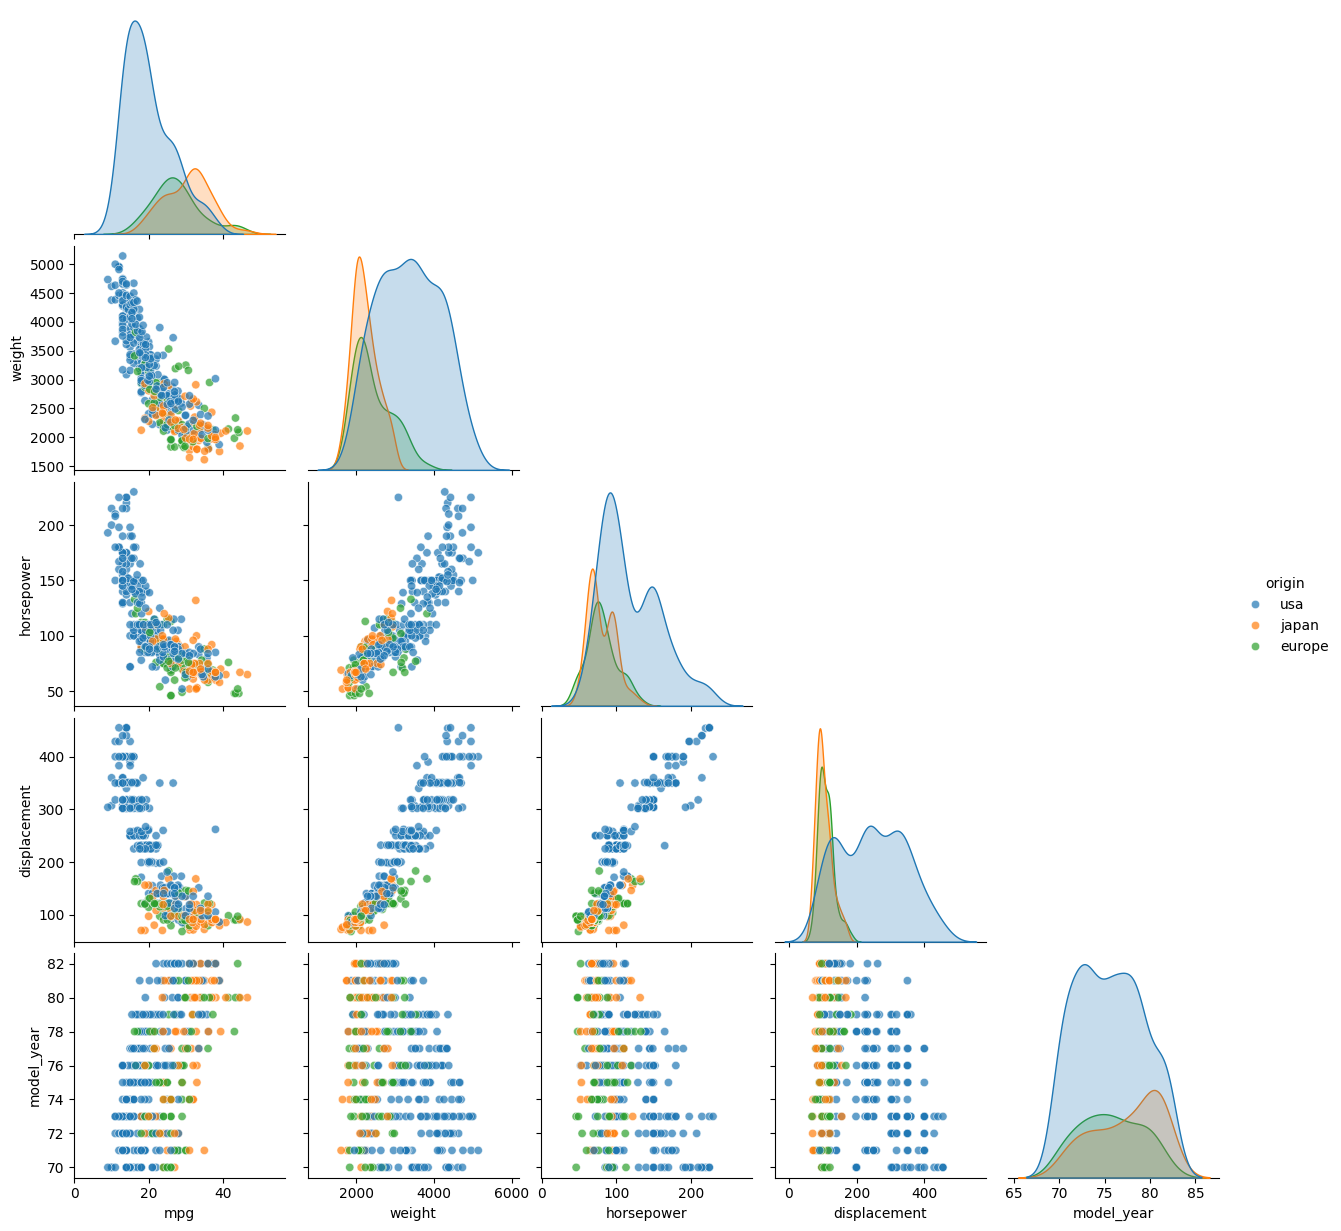

In [24]:
# Ejercicio 24
variables_pairplot = ["mpg", "weight", "horsepower", "displacement", "model_year", "origin"]
datos_pairplot = datos_autos[variables_pairplot].dropna()

sns.pairplot(
    datos_pairplot,
    vars=["mpg", "weight", "horsepower", "displacement", "model_year"],
    hue="origin",
    corner=True,
    plot_kws={"alpha": 0.7}
)
plt.show()

El pairplot permite revisar muchas relaciones a la vez. Ayuda a ver asociaciones negativas con `mpg` y posibles redundancias entre variables del motor y peso.

#### 25. Registro de decisiones

Elabora un registro de decisiones para preparar un análisis posterior: nulos de `horsepower`, `name`, `origin`, outliers de potencia y variables altamente correlacionadas.

In [25]:
# Ejercicio 25
registro_decisiones = pd.DataFrame({
    "tema": [
        "Nulos de horsepower",
        "Variable name",
        "Variable origin",
        "Outliers de horsepower",
        "Variables altamente correlacionadas"
    ],
    "decisión para EDA": [
        "Trabajar con filas completas cuando el análisis use horsepower.",
        "Usarla para interpretar modelos repetidos o vehículos extremos.",
        "Analizarla como categoría para comparar grupos.",
        "Revisarlos en contexto con nombre, cilindros, desplazamiento y peso.",
        "Revisar correlaciones para entender relaciones entre predictores."
    ],
    "decisión para modelado": [
        "Imputar con mediana o con una estrategia por grupos antes de entrenar.",
        "No usarla directamente como predictor sin transformar o extraer marca.",
        "Codificarla como variable categórica.",
        "No eliminarlos automáticamente; validar si son plausibles.",
        "Evitar usar todas sin revisar redundancia o aplicar regularización."
    ]
})

registro_decisiones

,tema,decisión para EDA,decisión para modelado
0,Nulos de horsepower,Trabajar con filas completas cuando el análisi...,Imputar con mediana o con una estrategia por g...
1,Variable name,Usarla para interpretar modelos repetidos o ve...,No usarla directamente como predictor sin tran...
2,Variable origin,Analizarla como categoría para comparar grupos.,Codificarla como variable categórica.
3,Outliers de horsepower,"Revisarlos en contexto con nombre, cilindros, ...",No eliminarlos automáticamente; validar si son...
4,Variables altamente correlacionadas,Revisar correlaciones para entender relaciones...,Evitar usar todas sin revisar redundancia o ap...
